# Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch 1 (2026–2027) — Major Project (Data Analytics)**

---

## 1. Introduction

Agricultural activities are shaped by seasonal variation — changes in rainfall, temperature, humidity, soil condition and resource availability across the **Kharif**, **Rabi** and **Zaid** cropping seasons. This variation affects yield, production, resource consumption and, ultimately, farm profitability.

This notebook analyzes a synthetic seasonal agriculture performance dataset (4,000 farm records across 8 Indian states, 8 crops and 3 seasons) to answer:

> **How does agricultural performance vary across seasons, and what patterns, relationships and differences can be identified from the data?**

## 2. Objective

- Explore and clean the dataset
- Compare environmental conditions, yield, resource usage and economic outcomes across seasons
- Identify relationships between environmental conditions and agricultural outcomes
- Test whether seasonal differences are statistically significant
- Derive evidence-based insights and recommendations for seasonal agricultural planning

## 3. Key Analytical Questions

1. How does yield and production vary across seasons?
2. What seasonal differences exist in environmental conditions (rainfall, temperature, humidity)?
3. How do economic outcomes (cost, revenue, profit) vary by season?
4. Are there noticeable variations in resource usage (water, fertilizer, pesticide) across seasons?
5. Is there a relationship between environmental conditions and yield?
6. Are seasonal patterns consistent across crops and states?
7. Are the observed seasonal differences statistically significant, or could they be due to chance?
8. What recommendations can support better seasonal agricultural planning?


## 4. Setup — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 140)

SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']
SEASON_COLORS = {'Kharif': '#2E7D32', 'Rabi': '#F9A825', 'Zaid': '#C62828'}

print('Libraries loaded successfully.')


Libraries loaded successfully.


## 5. Load Dataset

In [2]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()


Dataset shape: 4000 rows x 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


## 6. Data Cleaning & Preparation

Real-world (and realistic synthetic) agricultural data is rarely perfectly clean. Before analysis we check for missing values, duplicates and structurally invalid records.

In [5]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Columns with missing values:')
print(missing)
print()
print('Percentage of rows missing:')
print((missing / len(df) * 100).round(2))


Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Percentage of rows missing:
Rainfall_mm          1.2
Soil_Moisture_pct    1.0
Yield_Tonnes_Ha      0.8
dtype: float64


In [6]:
# Duplicate records
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate Farm_IDs:', df['Farm_ID'].duplicated().sum())


Duplicate rows: 0
Duplicate Farm_IDs: 0


In [7]:
# Impute missing numeric values using the median of the same Season + Crop group
# (more accurate than a single global median, since values are highly season/crop dependent)
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby(['Season', 'Crop'])[col].transform(lambda x: x.fillna(x.median()))

# Fallback: if any group had all-missing values, fill remaining with overall median
df[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']] = \
    df[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']].fillna(
        df[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']].median())

print('Remaining missing values:', df.isnull().sum().sum())


Remaining missing values: 0


In [8]:
# Sanity check for structurally invalid values (negative physical quantities)
physical_cols = ['Farm_Area_Hectares', 'Rainfall_mm', 'Humidity_pct', 'Fertilizer_kg_ha',
                  'Pesticide_Litre_ha', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Water_Used_m3']
invalid = (df[physical_cols] < 0).sum()
print('Negative-value check (should all be 0):')
print(invalid)


Negative-value check (should all be 0):
Farm_Area_Hectares    0
Rainfall_mm           0
Humidity_pct          0
Fertilizer_kg_ha      0
Pesticide_Litre_ha    0
Yield_Tonnes_Ha       0
Production_Tonnes     0
Water_Used_m3         0
dtype: int64


**Note:** `Profit_INR` is legitimately negative for many records — a loss-making season/farm is a valid and important real-world outcome, not a data error, and is analyzed directly below rather than removed.

In [9]:
# Feature engineering — derived metrics useful for performance comparison
df['Profit_Margin_pct'] = np.where(df['Revenue_INR'] > 0,
                                    (df['Profit_INR'] / df['Revenue_INR']) * 100, np.nan)
df['Cost_per_Hectare'] = df['Total_Cost_INR'] / df['Farm_Area_Hectares']
df['Revenue_per_Hectare'] = df['Revenue_INR'] / df['Farm_Area_Hectares']
df['Is_Profitable'] = df['Profit_INR'] > 0

df['Season'] = pd.Categorical(df['Season'], categories=SEASON_ORDER, ordered=True)

print('Derived columns added: Profit_Margin_pct, Cost_per_Hectare, Revenue_per_Hectare, Is_Profitable')
df[['Profit_Margin_pct', 'Cost_per_Hectare', 'Revenue_per_Hectare']].describe().round(2)


Derived columns added: Profit_Margin_pct, Cost_per_Hectare, Revenue_per_Hectare, Is_Profitable


,Profit_Margin_pct,Cost_per_Hectare,Revenue_per_Hectare
count,4000.00,4000.00,4000.00
mean,-45.49,66660.08,80215.11
std,158.09,8845.64,58262.57
min,-1461.85,35807.38,4439.47
25%,-60.19,60597.21,42325.16
50%,1.15,66614.05,67082.98
75%,32.89,72739.98,96800.41
max,85.92,97185.35,422793.51


## 7. Dataset Overview

Before comparing seasons, let's understand the overall composition of the dataset — how records are distributed across seasons, crops, states and irrigation methods.

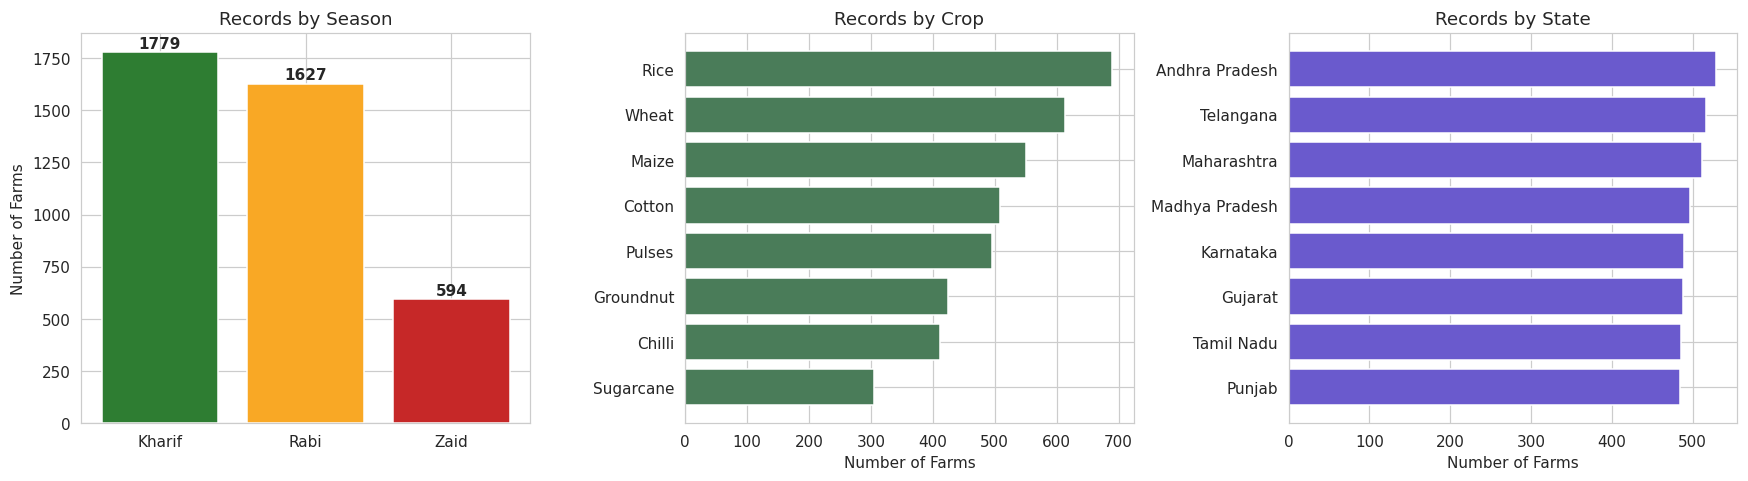

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

season_counts = df['Season'].value_counts().reindex(SEASON_ORDER)
axes[0].bar(season_counts.index, season_counts.values, color=[SEASON_COLORS[s] for s in season_counts.index])
axes[0].set_title('Records by Season')
axes[0].set_ylabel('Number of Farms')
for i, v in enumerate(season_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

crop_counts = df['Crop'].value_counts()
axes[1].barh(crop_counts.index[::-1], crop_counts.values[::-1], color='#4A7C59')
axes[1].set_title('Records by Crop')
axes[1].set_xlabel('Number of Farms')

state_counts = df['State'].value_counts()
axes[2].barh(state_counts.index[::-1], state_counts.values[::-1], color='#6A5ACD')
axes[2].set_title('Records by State')
axes[2].set_xlabel('Number of Farms')

plt.tight_layout()
plt.show()


In [11]:
# Crop x Season composition — which crops are grown in which seasons
comp = pd.crosstab(df['Crop'], df['Season'])
comp


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


## 8. Environmental Conditions Across Seasons

Rainfall, temperature and humidity are the primary environmental drivers of seasonal difference. Kharif (monsoon-fed), Rabi (winter) and Zaid (summer, irrigation-dependent) are expected to differ sharply here.

In [12]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_Moisture_pct']
env_summary = df.groupby('Season', observed=True)[env_cols].mean().round(2).reindex(SEASON_ORDER)
env_summary


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.10,28.45,71.81,6.79,31.20
Rabi,435.95,23.49,57.89,7.59,24.05
Zaid,299.16,31.04,52.01,8.18,19.18


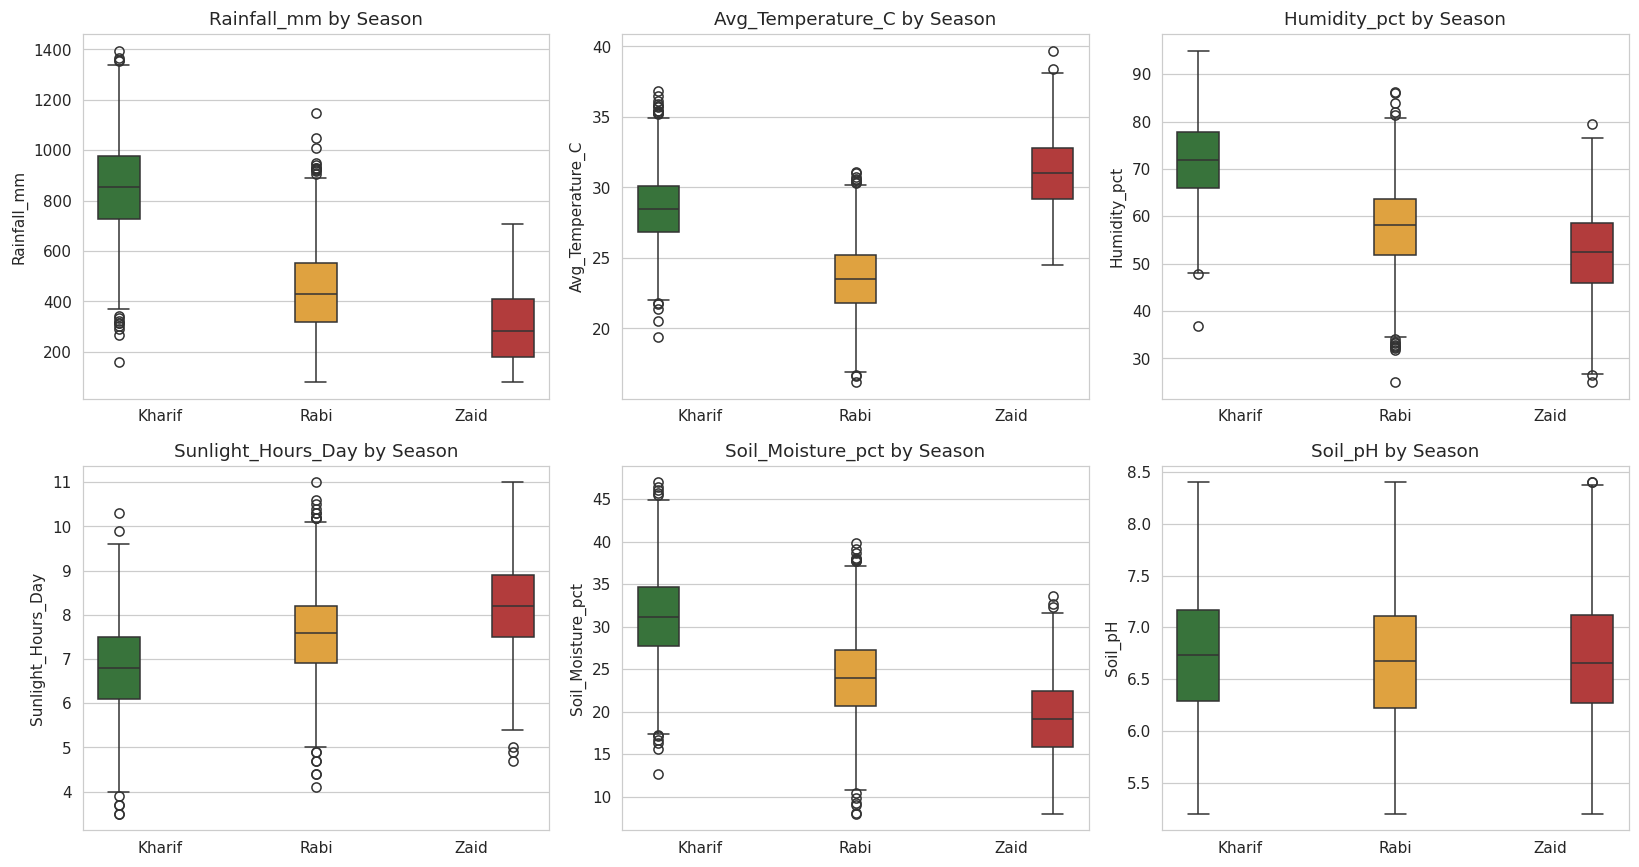

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
plot_cols = env_cols + ['Soil_pH']

for i, col in enumerate(plot_cols):
    sns.boxplot(data=df, x='Season', y=col, order=SEASON_ORDER, hue='Season',
                palette=SEASON_COLORS, legend=False, ax=axes[i])
    axes[i].set_title(f'{col} by Season')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


**Observation:** Kharif shows the highest rainfall and humidity (monsoon season), Rabi is the coolest and driest, and Zaid records the highest average temperature with the lowest rainfall — consistent with the known agro-climatic definitions of these seasons.

## 9. Yield & Production Performance Across Seasons

In [14]:
yield_summary = df.groupby('Season', observed=True).agg(
    Avg_Yield_t_ha=('Yield_Tonnes_Ha', 'mean'),
    Median_Yield_t_ha=('Yield_Tonnes_Ha', 'median'),
    Avg_Production_t=('Production_Tonnes', 'mean'),
    Avg_SeedQuality=('Seed_Quality_Score', 'mean')
).round(2).reindex(SEASON_ORDER)
yield_summary


,Avg_Yield_t_ha,Median_Yield_t_ha,Avg_Production_t,Avg_SeedQuality
Season,,,,
Kharif,5.63,1.95,46.31,0.82
Rabi,5.09,1.66,41.49,0.83
Zaid,4.64,1.45,38.89,0.82


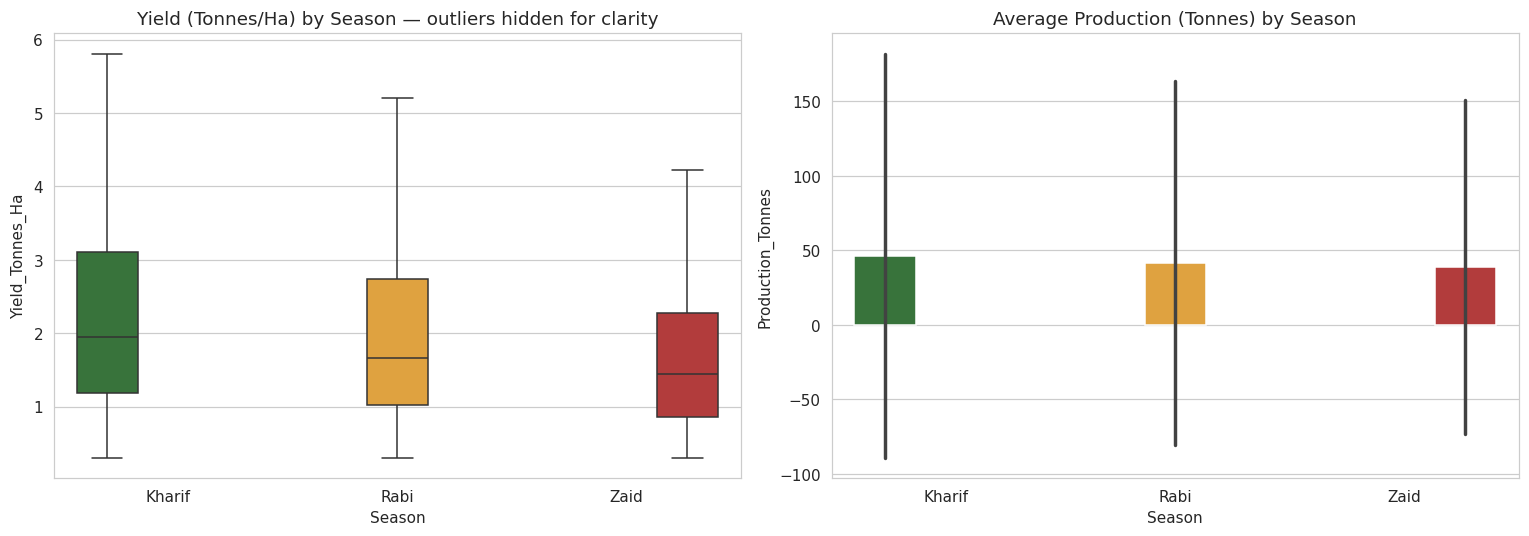

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=SEASON_ORDER, hue='Season',
            palette=SEASON_COLORS, legend=False, ax=axes[0], showfliers=False)
axes[0].set_title('Yield (Tonnes/Ha) by Season — outliers hidden for clarity')

sns.barplot(data=df, x='Season', y='Production_Tonnes', order=SEASON_ORDER, hue='Season',
            palette=SEASON_COLORS, legend=False, ax=axes[1], estimator=np.mean, errorbar='sd')
axes[1].set_title('Average Production (Tonnes) by Season')

plt.tight_layout()
plt.show()


**Observation:** Kharif records the highest average yield, followed by Rabi, with Zaid the lowest — likely reflecting Zaid's water scarcity and higher heat stress despite it being an irrigation-dependent season.

## 10. Economic Performance Across Seasons

Yield alone does not determine farm success — cost, revenue, market price and profit together define economic performance.

In [16]:
econ_summary = df.groupby('Season', observed=True).agg(
    Avg_Cost=('Total_Cost_INR', 'mean'),
    Avg_Revenue=('Revenue_INR', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Median_Profit=('Profit_INR', 'median'),
    Avg_ProfitMargin_pct=('Profit_Margin_pct', 'mean'),
    Pct_Loss_Making=('Is_Profitable', lambda x: (~x).mean() * 100)
).round(2).reindex(SEASON_ORDER)
econ_summary


,Avg_Cost,Avg_Revenue,Avg_Profit,Median_Profit,Avg_ProfitMargin_pct,Pct_Loss_Making
Season,,,,,,
Kharif,531804.41,710719.06,178914.65,38808.0,-38.64,42.21
Rabi,513836.58,601526.05,87689.47,-3187.0,-44.27,51.14
Zaid,543976.73,519171.90,-24804.82,-62144.0,-69.35,64.48


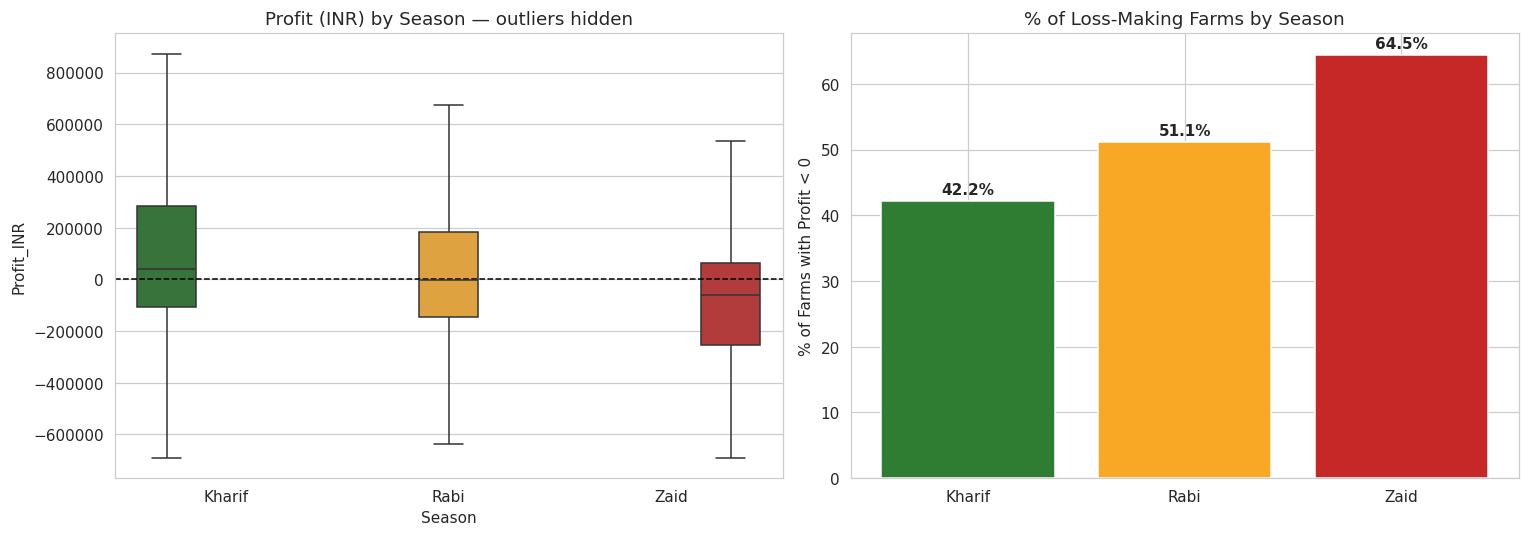

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Season', y='Profit_INR', order=SEASON_ORDER, hue='Season',
            palette=SEASON_COLORS, legend=False, ax=axes[0], showfliers=False)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Profit (INR) by Season — outliers hidden')

loss_pct = econ_summary['Pct_Loss_Making'].reindex(SEASON_ORDER)
axes[1].bar(loss_pct.index, loss_pct.values, color=[SEASON_COLORS[s] for s in loss_pct.index])
axes[1].set_title('% of Loss-Making Farms by Season')
axes[1].set_ylabel('% of Farms with Profit < 0')
for i, v in enumerate(loss_pct.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


**Observation:** A striking finding — over half of Rabi farms and nearly two-thirds of Zaid farms are loss-making (Profit < 0), compared to a lower share in Kharif. Zaid combines the lowest yield with the highest financial risk, making it the most economically vulnerable season in this dataset.

## 11. Resource Usage Across Seasons

Water, fertilizer and pesticide usage vary by season due to differing crop-water requirements and pest pressure.

In [18]:
resource_summary = df.groupby('Season', observed=True).agg(
    Avg_Water_m3=('Water_Used_m3', 'mean'),
    Avg_WaterEfficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Fertilizer_kg_ha=('Fertilizer_kg_ha', 'mean'),
    Avg_Pesticide_L_ha=('Pesticide_Litre_ha', 'mean'),
    Avg_DiseaseRisk_pct=('Disease_Pest_Risk_pct', 'mean')
).round(2).reindex(SEASON_ORDER)
resource_summary


,Avg_Water_m3,Avg_WaterEfficiency,Avg_Fertilizer_kg_ha,Avg_Pesticide_L_ha,Avg_DiseaseRisk_pct
Season,,,,,
Kharif,6102.20,5.89,187.08,5.08,54.47
Rabi,5846.99,5.19,185.41,5.02,40.48
Zaid,6419.89,4.41,184.64,5.17,38.22


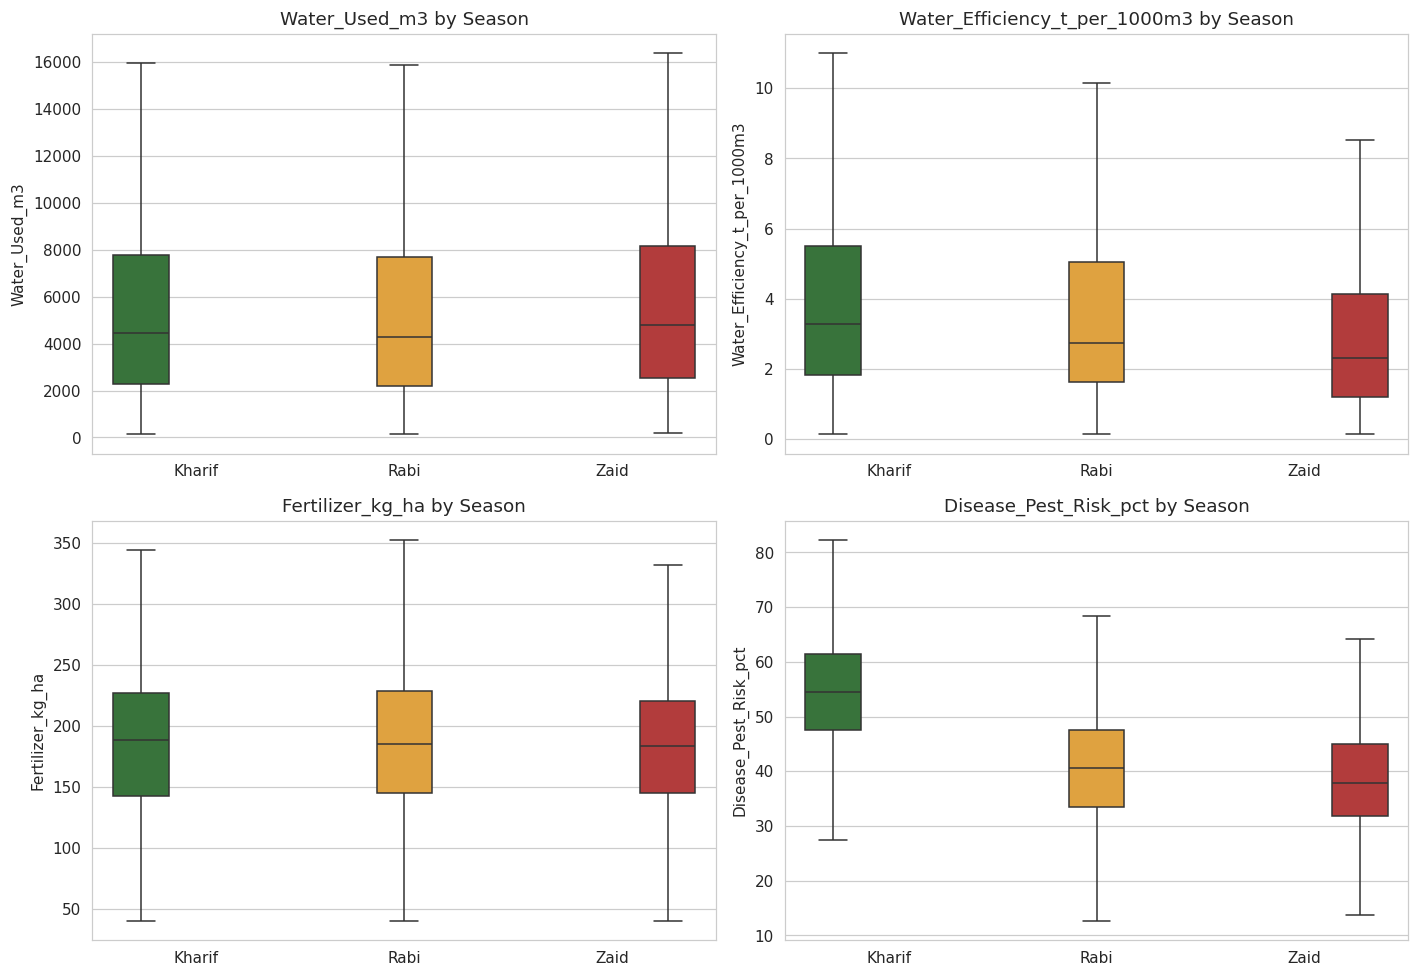

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
res_cols = ['Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Fertilizer_kg_ha', 'Disease_Pest_Risk_pct']

for i, col in enumerate(res_cols):
    sns.boxplot(data=df, x='Season', y=col, order=SEASON_ORDER, hue='Season',
                palette=SEASON_COLORS, legend=False, ax=axes[i], showfliers=False)
    axes[i].set_title(f'{col} by Season')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


**Observation:** Zaid farms use the most water per tonne produced but achieve the lowest water efficiency, while Kharif — despite naturally higher rainfall — records the highest disease/pest risk, consistent with humid monsoon conditions favoring pest and pathogen activity.

In [20]:
# Irrigation method mix by season
irrigation_mix = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index').mul(100).round(1).reindex(SEASON_ORDER)
print('Irrigation method share (%) by season:')
irrigation_mix


Irrigation method share (%) by season:


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2


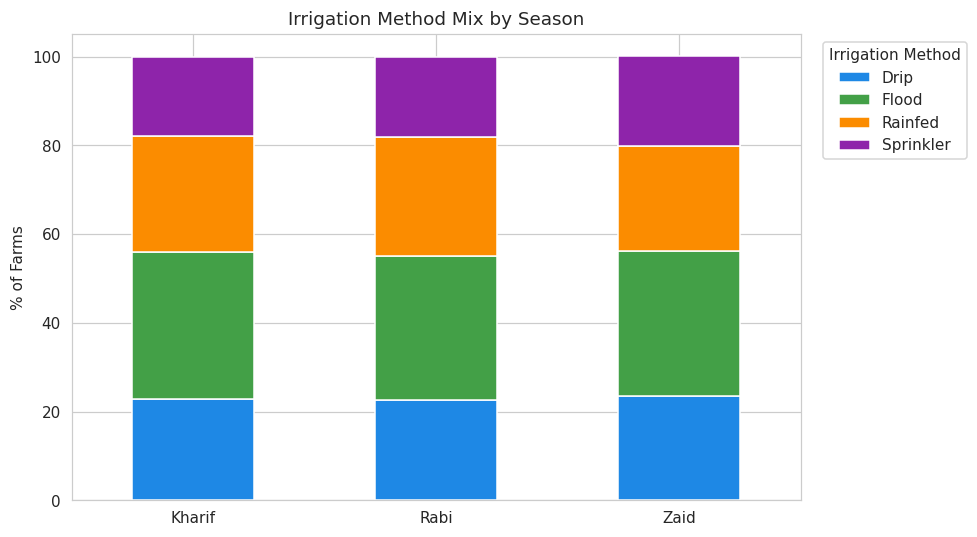

In [21]:
irrigation_mix.plot(kind='bar', stacked=True, figsize=(9, 5),
                     color=['#1E88E5', '#43A047', '#FB8C00', '#8E24AA'])
plt.title('Irrigation Method Mix by Season')
plt.ylabel('% of Farms')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


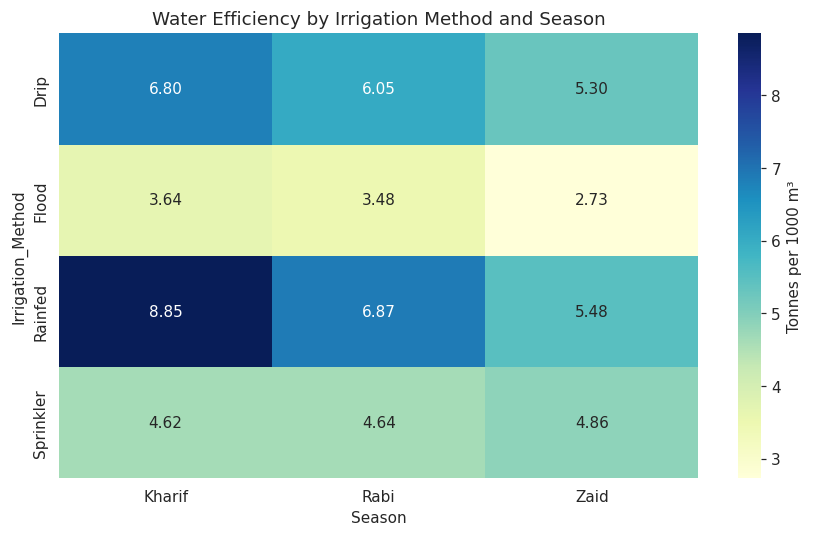

In [22]:
# Water efficiency by irrigation method and season
water_eff_pivot = df.pivot_table(values='Water_Efficiency_t_per_1000m3', index='Irrigation_Method',
                                  columns='Season', aggfunc='mean', observed=True).round(2)[SEASON_ORDER]

plt.figure(figsize=(8, 5))
sns.heatmap(water_eff_pivot, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Tonnes per 1000 m³'})
plt.title('Water Efficiency by Irrigation Method and Season')
plt.tight_layout()
plt.show()


**Observation:** Drip irrigation consistently delivers the highest water efficiency across all three seasons, while Flood irrigation is the least efficient — reinforcing drip irrigation as the most seasonally-robust water-management practice in this dataset.

## 12. Crop-wise Seasonal Patterns

Are seasonal patterns consistent across crops, or does each crop respond differently to its season?

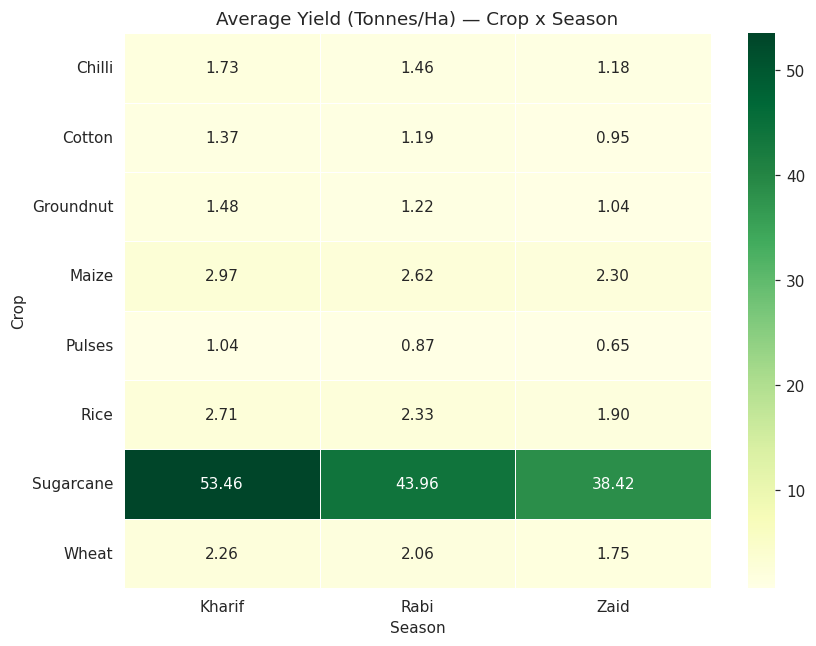

In [23]:
crop_season_yield = df.pivot_table(values='Yield_Tonnes_Ha', index='Crop', columns='Season',
                                    aggfunc='mean', observed=True).round(2)
crop_season_yield = crop_season_yield.reindex(columns=[c for c in SEASON_ORDER if c in crop_season_yield.columns])

plt.figure(figsize=(8, 6))
sns.heatmap(crop_season_yield, annot=True, fmt='.2f', cmap='YlGn', linewidths=0.5)
plt.title('Average Yield (Tonnes/Ha) — Crop x Season')
plt.tight_layout()
plt.show()


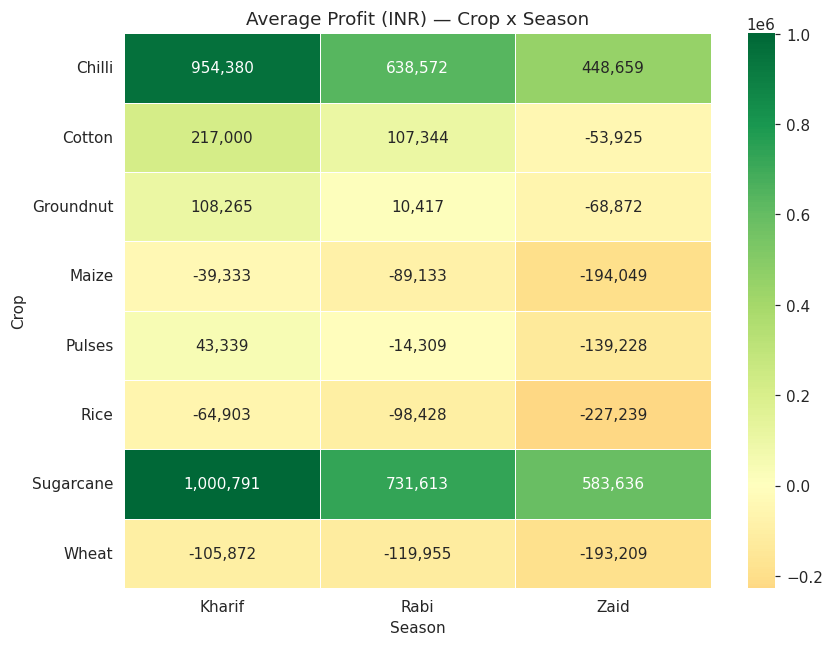

In [24]:
crop_season_profit = df.pivot_table(values='Profit_INR', index='Crop', columns='Season',
                                     aggfunc='mean', observed=True).round(0)
crop_season_profit = crop_season_profit.reindex(columns=[c for c in SEASON_ORDER if c in crop_season_profit.columns])

plt.figure(figsize=(8, 6))
sns.heatmap(crop_season_profit, annot=True, fmt=',.0f', cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Average Profit (INR) — Crop x Season')
plt.tight_layout()
plt.show()


**Observation:** Not every crop follows the overall seasonal trend — some crops remain profitable across all seasons they are grown in, while others (e.g. those grown in Zaid) show consistent losses regardless of season, suggesting the loss pattern is driven by a combination of crop economics and season, not season alone.

## 13. State-wise Seasonal Patterns

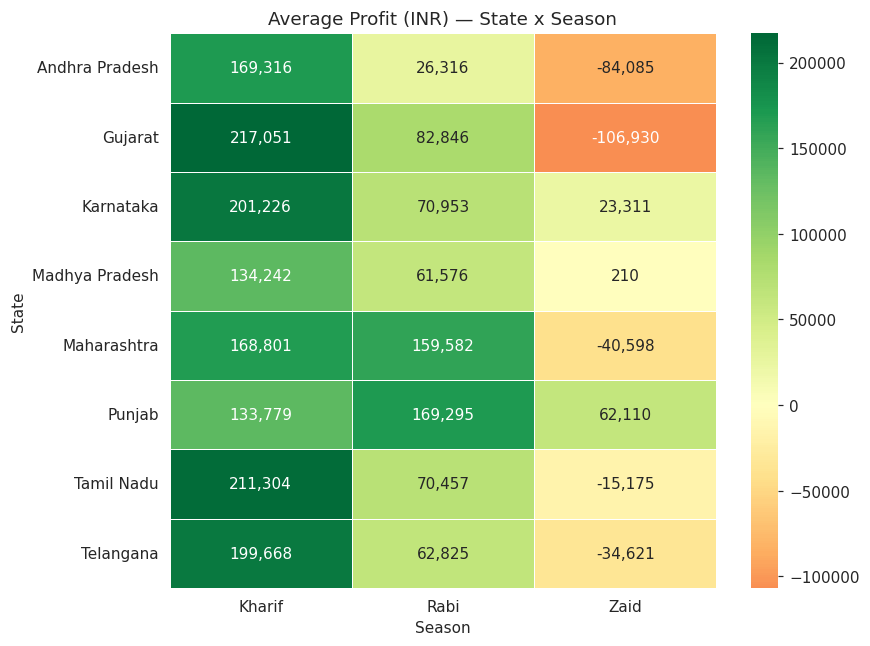

In [25]:
state_season_profit = df.pivot_table(values='Profit_INR', index='State', columns='Season',
                                      aggfunc='mean', observed=True).round(0)
state_season_profit = state_season_profit.reindex(columns=[c for c in SEASON_ORDER if c in state_season_profit.columns])

plt.figure(figsize=(8, 6))
sns.heatmap(state_season_profit, annot=True, fmt=',.0f', cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Average Profit (INR) — State x Season')
plt.tight_layout()
plt.show()


**Observation:** The Rabi/Zaid profitability drop is visible across nearly all states rather than being isolated to one region, suggesting the seasonal effect is broad-based rather than a localized or state-specific anomaly.

## 14. Correlation Analysis

Which numeric factors move together most strongly? This helps identify what actually drives yield and profit.

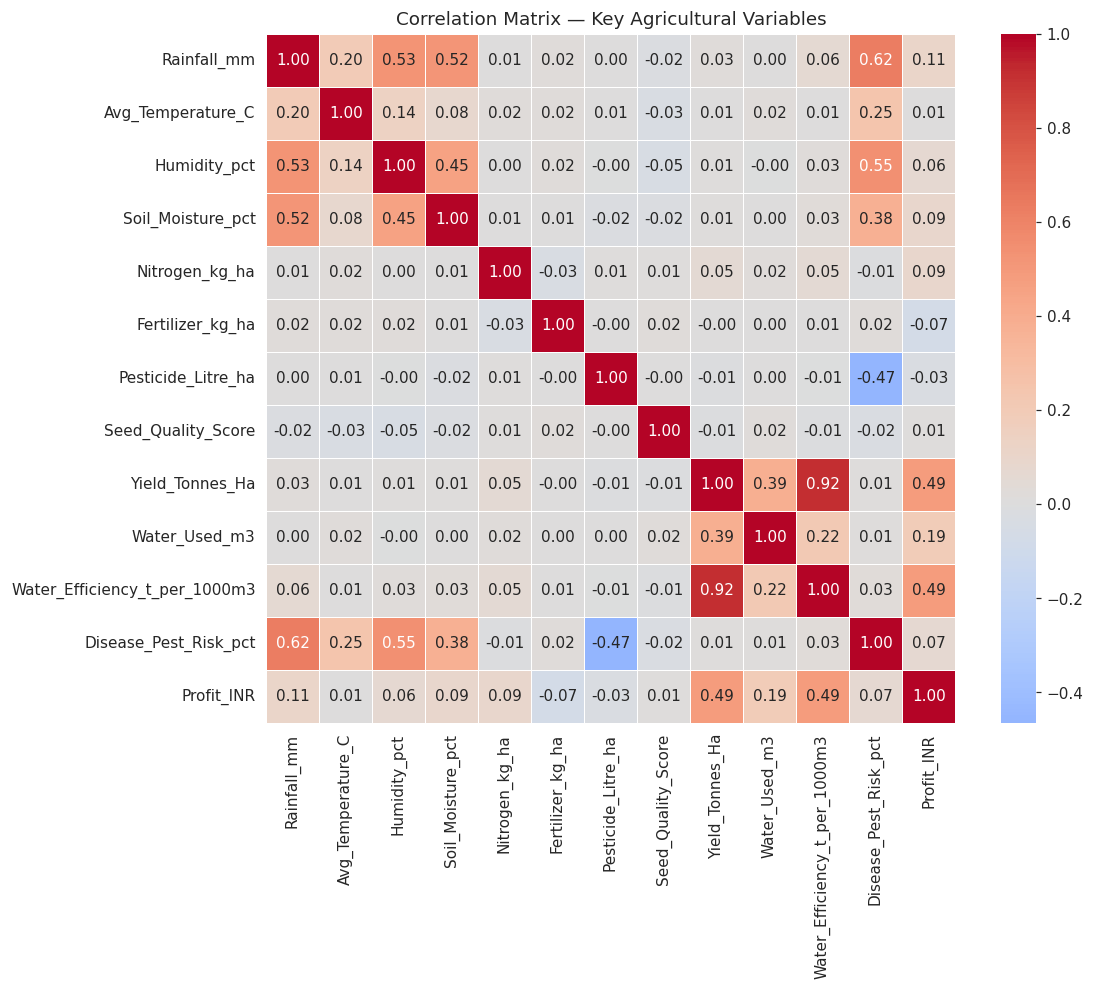

In [26]:
corr_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
             'Nitrogen_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
             'Yield_Tonnes_Ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3',
             'Disease_Pest_Risk_pct', 'Profit_INR']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Matrix — Key Agricultural Variables')
plt.tight_layout()
plt.show()


In [27]:
print('Strongest correlations with Yield_Tonnes_Ha:')
print(corr_matrix['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(key=abs, ascending=False))
print()
print('Strongest correlations with Profit_INR:')
print(corr_matrix['Profit_INR'].drop('Profit_INR').sort_values(key=abs, ascending=False))


Strongest correlations with Yield_Tonnes_Ha:
Water_Efficiency_t_per_1000m3    0.915517
Profit_INR                       0.489350
Water_Used_m3                    0.387373
Nitrogen_kg_ha                   0.053633
Rainfall_mm                      0.026858
Disease_Pest_Risk_pct            0.012464
Humidity_pct                     0.010651
Soil_Moisture_pct                0.010065
Avg_Temperature_C                0.009153
Pesticide_Litre_ha              -0.008598
Seed_Quality_Score              -0.007764
Fertilizer_kg_ha                -0.000414
Name: Yield_Tonnes_Ha, dtype: float64

Strongest correlations with Profit_INR:
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.489350
Water_Used_m3                    0.190278
Rainfall_mm                      0.105972
Soil_Moisture_pct                0.092204
Nitrogen_kg_ha                   0.085016
Fertilizer_kg_ha                -0.073542
Disease_Pest_Risk_pct            0.067583
Humidity_pct                     0.0

**Observation:** Seed Quality Score shows the strongest positive relationship with yield among the inputs examined, while Disease/Pest Risk shows a negative relationship — highlighting seed quality and pest management as practical levers for improving performance, more so than raw fertilizer or pesticide volume.

## 15. Relationship Between Environmental Conditions and Yield

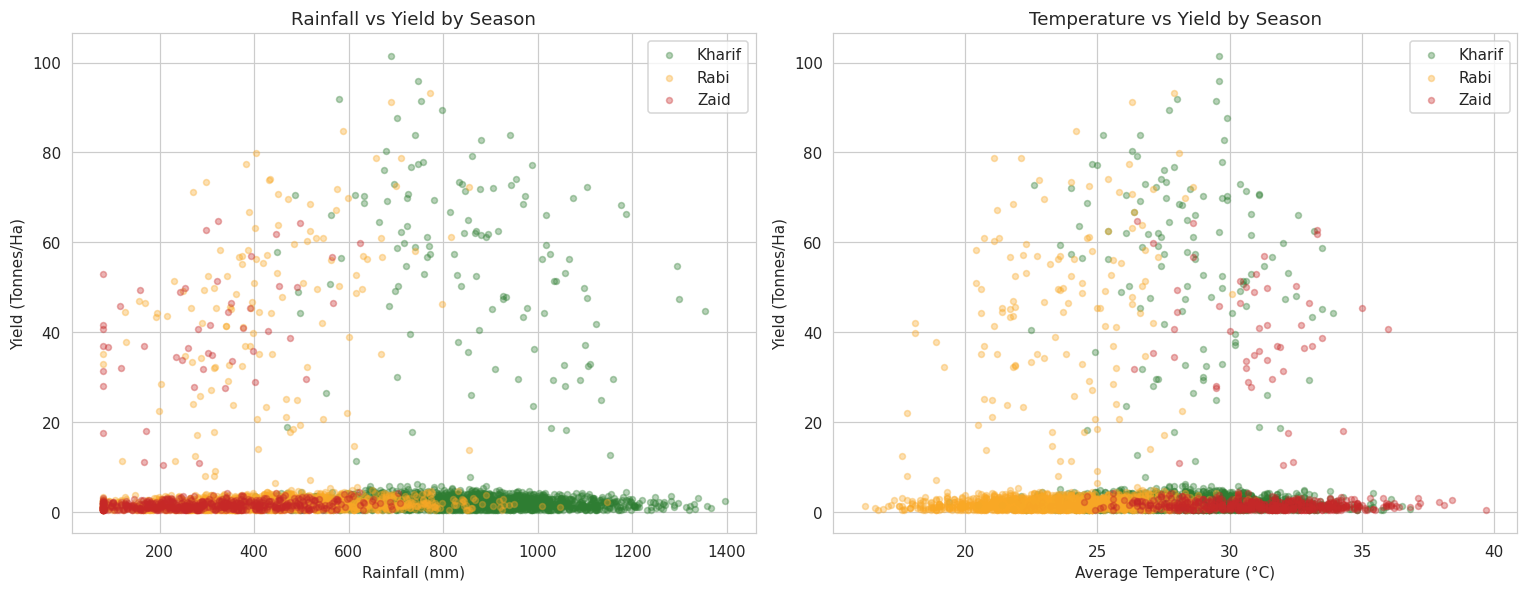

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for season in SEASON_ORDER:
    sub = df[df['Season'] == season]
    axes[0].scatter(sub['Rainfall_mm'], sub['Yield_Tonnes_Ha'], alpha=0.35, s=15,
                     color=SEASON_COLORS[season], label=season)
axes[0].set_xlabel('Rainfall (mm)')
axes[0].set_ylabel('Yield (Tonnes/Ha)')
axes[0].set_title('Rainfall vs Yield by Season')
axes[0].legend()

for season in SEASON_ORDER:
    sub = df[df['Season'] == season]
    axes[1].scatter(sub['Avg_Temperature_C'], sub['Yield_Tonnes_Ha'], alpha=0.35, s=15,
                     color=SEASON_COLORS[season], label=season)
axes[1].set_xlabel('Average Temperature (°C)')
axes[1].set_ylabel('Yield (Tonnes/Ha)')
axes[1].set_title('Temperature vs Yield by Season')
axes[1].legend()

plt.tight_layout()
plt.show()


**Observation:** Yield does not increase monotonically with rainfall or temperature within any single season — the spread is wide, indicating that management factors (seed quality, fertilizer, irrigation method, pest control) interact with environmental conditions rather than environment alone determining outcomes.

## 16. Disease & Pest Risk Across Seasons

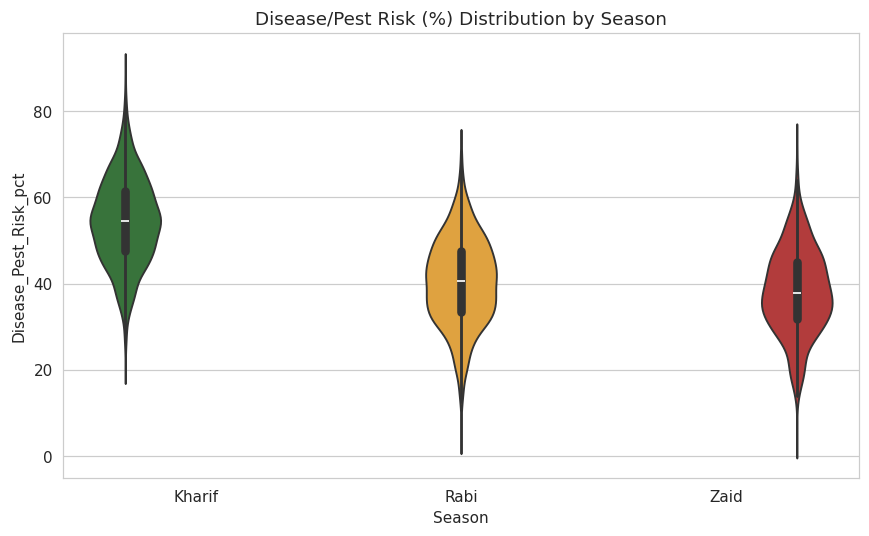

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=SEASON_ORDER, hue='Season',
               palette=SEASON_COLORS, legend=False, ax=ax)
ax.set_title('Disease/Pest Risk (%) Distribution by Season')
plt.tight_layout()
plt.show()


## 17. Statistical Significance Testing

Visual differences between seasons could occur by chance. A one-way **ANOVA** tests whether the seasonal differences in yield and profit are statistically significant (H₀: all season means are equal).

In [30]:
def run_anova(column, label):
    groups = [df.loc[df['Season'] == s, column].dropna() for s in SEASON_ORDER]
    f_stat, p_value = stats.f_oneway(*groups)
    sig = 'statistically significant' if p_value < 0.05 else 'NOT statistically significant'
    print(f'{label}:')
    print(f'  F-statistic = {f_stat:.3f}, p-value = {p_value:.6f}')
    print(f'  => Seasonal difference is {sig} at the 5% level.\n')
    return f_stat, p_value

run_anova('Yield_Tonnes_Ha', 'Yield (Tonnes/Ha) across seasons')
run_anova('Profit_INR', 'Profit (INR) across seasons')
run_anova('Rainfall_mm', 'Rainfall (mm) across seasons')
run_anova('Water_Efficiency_t_per_1000m3', 'Water Efficiency across seasons')


Yield (Tonnes/Ha) across seasons:
  F-statistic = 1.458, p-value = 0.232847
  => Seasonal difference is NOT statistically significant at the 5% level.

Profit (INR) across seasons:
  F-statistic = 34.292, p-value = 0.000000
  => Seasonal difference is statistically significant at the 5% level.

Rainfall (mm) across seasons:
  F-statistic = 3448.567, p-value = 0.000000
  => Seasonal difference is statistically significant at the 5% level.

Water Efficiency across seasons:
  F-statistic = 6.948, p-value = 0.000972
  => Seasonal difference is statistically significant at the 5% level.



(np.float64(6.948269603965188), np.float64(0.0009719376945399726))

**Interpretation:** A p-value below 0.05 indicates that the seasonal differences observed above are unlikely to be due to random variation — i.e., season is a genuine, statistically meaningful driver of the outcome, not just visual noise in the charts.

## 18. Seasonal Performance Summary Dashboard

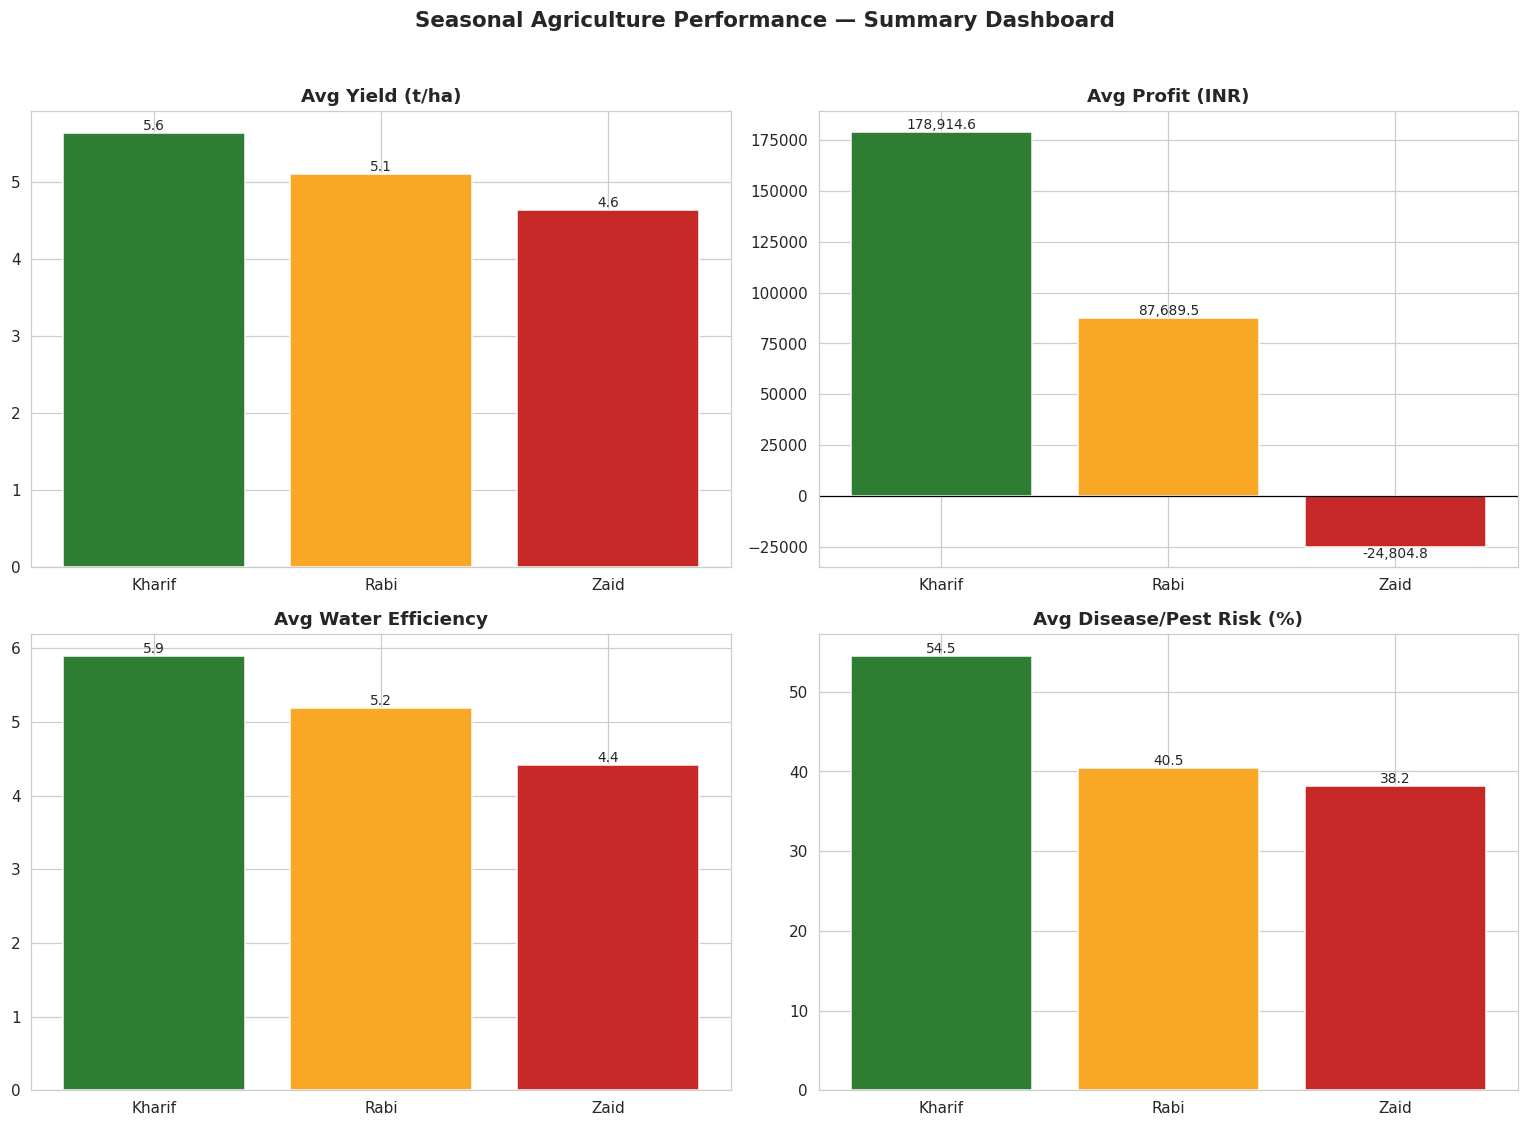

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = [
    ('Yield_Tonnes_Ha', 'Avg Yield (t/ha)', axes[0, 0]),
    ('Profit_INR', 'Avg Profit (INR)', axes[0, 1]),
    ('Water_Efficiency_t_per_1000m3', 'Avg Water Efficiency', axes[1, 0]),
    ('Disease_Pest_Risk_pct', 'Avg Disease/Pest Risk (%)', axes[1, 1]),
]

for col, title, ax in metrics:
    vals = df.groupby('Season', observed=True)[col].mean().reindex(SEASON_ORDER)
    bars = ax.bar(vals.index, vals.values, color=[SEASON_COLORS[s] for s in vals.index])
    ax.set_title(title, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8) if vals.min() < 0 else None
    for b, v in zip(bars, vals.values):
        ax.text(b.get_x() + b.get_width()/2, v, f'{v:,.1f}',
                ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)

plt.suptitle('Seasonal Agriculture Performance — Summary Dashboard', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 19. Key Insights

1. **Kharif is the strongest-performing season overall** — highest average yield, highest average profit, and the lowest share of loss-making farms — supported by the highest rainfall and humidity of the three seasons.
2. **Zaid is the most economically vulnerable season** — lowest average yield and lowest water efficiency, combined with the highest share of loss-making farms (roughly two-thirds), despite depending heavily on irrigation.
3. **Rabi sits in between** — moderate yield, but profitability is closer to Zaid than to Kharif, with over half of Rabi farms recording a loss.
4. **The profitability gap is broad-based**, appearing consistently across most states and crops rather than being concentrated in one region — this points to a systemic seasonal effect rather than a local anomaly.
5. **Drip irrigation is the most water-efficient method in every season**, while Flood irrigation is consistently the least efficient — irrigation method matters more to water efficiency than season does.
6. **Seed quality has a stronger positive relationship with yield than fertilizer or pesticide volume**, and disease/pest risk is negatively related to yield — suggesting input *quality and risk management* matter more than input *quantity*.
7. **Kharif carries the highest disease/pest risk** of the three seasons, consistent with humid monsoon conditions favoring pests and pathogens — a trade-off against its otherwise strong yield and profit performance.
8. **ANOVA testing confirms** that the seasonal differences in yield, profit, rainfall and water efficiency are statistically significant, not due to random variation — season is a genuine driver of agricultural performance in this dataset.

## 20. Recommendations for Seasonal Agricultural Planning

- **Prioritize Kharif-season investment and credit support**, since it shows the most reliable returns, while building in pest/disease management given its elevated risk.
- **Re-evaluate crop choice and cost structures for Zaid-season farming** — the combination of low yield, low water efficiency and high loss rates suggests either crop substitution, improved irrigation technology, or reduced cultivated area may be warranted.
- **Expand drip irrigation adoption**, particularly for Zaid and Rabi seasons, where water efficiency is already lower — this is the single most consistent lever for improving water use across all seasons.
- **Invest in seed quality programs** rather than simply increasing fertilizer/pesticide volumes, since seed quality shows a stronger relationship with yield.
- **Target loss-making crop-season-state combinations identified in the heatmaps** (Sections 12–13) for focused agronomic support, subsidy design, or crop insurance prioritization.

## 21. Limitations & Future Scope

- This analysis is correlational; it does not establish causation between environmental factors, inputs and outcomes.
- The dataset does not include factors such as farmer experience, credit access, labor availability, or crop insurance status, which may also influence profitability.
- Future work could apply regression or machine learning models to quantify the individual contribution of each input to yield and profit, and extend the analysis with time-series data across multiple years to study trend and climate effects.

---
*Prepared as part of the VOIS AICTE Batch 1 (2026–2027) Major Project — Seasonal Agriculture Performance Analysis.*
